# Intelligent Warehouse Robot Navigation
## D3: Implementation – Algorithms & Visualization

This notebook implements all search algorithms for the Warehouse Robot Navigation problem as defined in D1 and D2.

### Problem Summary
- Robot navigates an **N×N grid** from `(0,0)` → `(N-1, N-1)`
- Grid contains **static obstacles** and **k weighted items**
- Robot has a fixed **energy budget E₀** (each move costs 1 energy)
- **Objective**: Maximize total collected weight `W(π)` subject to `L(π) ≤ E₀`

### Algorithms Implemented
1. **BFS** – Breadth-First Search (uninformed)
2. **UCS** – Uniform Cost Search (uninformed)
3. **Greedy Best-First Search** (informed, uses h1 or h2)
4. **A\*** (informed, uses h1 or h2)
5. **Modified A\*** – Branch-and-Bound A* for maximum weight (optimal)

### Heuristics
- **h1**: Manhattan distance to nearest remaining item (or delivery)
- **h2**: h1 + MST over remaining items + distance from last item to delivery

## Importing all required libraries

In [22]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import random

## Environment – Grid, State, and Problem Definition

We define the `WarehouseEnv` class which encapsulates:
- The N×N grid with obstacles
- Item positions and weights
- State representation: `(x, y, remaining_items_frozenset, energy)`
- Transition model T(s, a)
- Visualization

In [23]:
class WarehouseEnv:
    """
    State is represented by (x, y, remaining_items_frozenset, energy)
    where (x, y) is the current position of the robot, remaining_items_frozenset is a frozenset of indices of items not yet collected, and energy is the remaining energy of the robot.
    Grid convention: (0,0) = top-left, (N-1,N-1) = bottom-right.
    Directions: Up=(-1,0), Down=(+1,0), Left=(0,-1), Right=(0,+1)
    """
    DIRECTIONS = {
        'UP':    (-1,  0),
        'DOWN':  ( 1,  0),
        'LEFT':  ( 0, -1),
        'RIGHT': ( 0,  1),
    }

    def __init__(self, N: int, energy: int, obstacle_positions: list,
                 item_positions: list, item_weights: list, seed: int = 42):
        """
        Parameters
        ----------
        N                  : grid size (N x N)
        energy             : initial energy budget E0
        obstacle_positions : list of (row, col) tuples
        item_positions     : list of (row, col) tuples (one per item)
        item_weights       : list of int weights (one per item)
        seed               : random seed (for reproducibility)
        """
        assert N >= 2, "Grid must be at least 2x2"
        assert len(item_positions) == len(item_weights), "Mismatch: positions vs weights"

        self.N = N
        self.E0 = energy
        self.obstacles = set(map(tuple, obstacle_positions))  # fast lookup for blocked cells
        self.item_positions = [tuple(p) for p in item_positions]   # index -> (r,c)
        self.item_weights = list(item_weights)                   # index -> weight
        self.k = len(item_positions)                             # number of items
        self.start = (0, 0)
        self.goal = (N-1, N-1)

        # Build a position -> item_index lookup for quick checks during state transitions
        self.pos_to_item = {pos: idx for idx, pos in enumerate(self.item_positions)}

        # Validate: no obstacles or items on start/goal
        assert self.start not in self.obstacles, "Start cell is blocked!"
        assert self.goal not in self.obstacles, "Goal cell is blocked!"
        for pos in self.item_positions:
            assert pos not in self.obstacles, f"Item at {pos} overlaps obstacle!"

    def initial_state(self):
        """s0 = (0, 0, frozenset(all item indices), E0)"""
        return (0, 0, frozenset(range(self.k)), self.E0)

    def is_goal(self, state) -> bool:
        x, y, _, e = state
        return (x, y) == self.goal and e >= 0

    def collected_weight(self, state) -> int:
        """Weight of items collected so far (i.e. NOT in remaining set)."""
        _, _, remaining, _ = state
        return sum(self.item_weights[i] for i in range(self.k)
                   if i not in remaining)

    # Transition model T(s, a) -> s'
    def get_successors(self, state):
        """
        Returns list of (action_name, successor_state, step_cost).

        Actions:
        Move(dir)  - cost 1, valid if adjacent cell is in-grid and not obstacle,
                    and e > 0.
        Pickup(i)  - cost 0, valid if robot is on item i and i in remaining.
                    (Auto-applied after each move in most algorithms, but
                    modeled as explicit action here for completeness.)
        """
        x, y, remaining, e = state
        successors = []

        # Move actions
        if e > 0:
            for name, (dr, dc) in self.DIRECTIONS.items():
                nx, ny = x + dr, y + dc
                if 0 <= nx < self.N and 0 <= ny < self.N:
                    if (nx, ny) not in self.obstacles:
                        new_e = e - 1
                        new_rem = remaining
                        # Auto-pickup if the new cell has an item
                        if (nx, ny) in self.pos_to_item:
                            idx = self.pos_to_item[(nx, ny)]
                            if idx in remaining:
                                new_rem = remaining - {idx}
                        new_state = (nx, ny, new_rem, new_e)
                        successors.append((f'Move({name})', new_state, 1))

        return successors

    # Grid validation
    def is_reachable(self) -> bool:
        """BFS check: is goal reachable from start ignoring energy?"""
        visited = {self.start}
        queue = deque([self.start])
        while queue:
            x, y = queue.popleft()
            if (x, y) == self.goal:
                return True
            for dr, dc in self.DIRECTIONS.values():
                nx, ny = x + dr, y + dc
                if (0 <= nx < self.N and 0 <= ny < self.N
                        and (nx, ny) not in self.obstacles
                        and (nx, ny) not in visited):
                    visited.add((nx, ny))
                    queue.append((nx, ny))
        return False

    # Visualization
    def render(self, path=None, title='Warehouse Grid', ax=None,
               explored=None, figsize=(7, 7)):
        """
        Render the warehouse grid.

        Color coding:
          White     = free cell
          Black     = obstacle
          Green     = start (0,0)
          Red       = goal  (N-1,N-1)
          Yellow    = item
          Blue      = path (if provided)
          LightBlue = explored cells (if provided)
        """
        show = ax is None
        if show:
            fig, ax = plt.subplots(figsize=figsize)

        grid = np.zeros((self.N, self.N))  # 0 = free

        for (r, c) in self.obstacles:
            grid[r][c] = 1  # obstacle

        if explored:
            for (r, c) in explored:
                if grid[r][c] == 0:
                    grid[r][c] = 5  # explored

        if path:
            for (r, c) in path:
                if grid[r][c] == 0 or grid[r][c] == 5:
                    grid[r][c] = 3  # path

        for (r, c) in self.item_positions:
            if grid[r][c] == 0:
                grid[r][c] = 2  # item

        grid[self.start] = 6  # start
        grid[self.goal] = 4   # goal

        # Mark items on path (collected)
        if path:
            path_set = set(path)
            for (r, c) in self.item_positions:
                if (r, c) in path_set:
                    grid[r][c] = 7  # collected item on path

        cmap = ListedColormap([
            '#FFFFFF',  # 0 free
            '#2C2C2C',  # 1 obstacle
            '#FFD700',  # 2 item
            '#4A90D9',  # 3 path
            '#E74C3C',  # 4 goal
            '#D0EAF8',  # 5 explored
            '#2ECC71',  # 6 start
            '#F39C12',  # 7 collected item on path
        ])

        ax.imshow(grid, cmap=cmap, vmin=0, vmax=7, origin='upper')

        # Grid lines
        for i in range(self.N + 1):
            ax.axhline(i - 0.5, color='#CCCCCC', linewidth=0.5)
            ax.axvline(i - 0.5, color='#CCCCCC', linewidth=0.5)

        # Item weight labels
        for idx, (r, c) in enumerate(self.item_positions):
            ax.text(c, r, f'W{self.item_weights[idx]}',
                    ha='center', va='center', fontsize=7,
                    color='#333333', fontweight='bold')

        # Start / Goal labels
        ax.text(0, 0, 'S', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
        ax.text(self.N - 1, self.N - 1, 'G', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

        # Legend
        legend_elements = [
            mpatches.Patch(color='#2ECC71', label='Start'),
            mpatches.Patch(color='#E74C3C', label='Goal'),
            mpatches.Patch(color='#2C2C2C', label='Obstacle'),
            mpatches.Patch(color='#FFD700', label='Item (uncollected)'),
            mpatches.Patch(color='#F39C12', label='Item (collected)'),
            mpatches.Patch(color='#4A90D9', label='Path'),
            mpatches.Patch(color='#D0EAF8', label='Explored'),
        ]
        ax.legend(handles=legend_elements, loc='upper left',
                  bbox_to_anchor=(1.01, 1), fontsize=8)

        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_xticks(range(self.N))
        ax.set_yticks(range(self.N))
        ax.tick_params(labelsize=7)

        if show:
            plt.tight_layout()
            plt.show()

print("WarehouseEnv defined.")

WarehouseEnv defined.


## Problem Factory – Easy / Medium / Hard Instances

We define three test instances that will be reused across all algorithms for comparison.

In [24]:
def make_problem(difficulty='easy', seed=42):
    """
    Returns a WarehouseEnv configured as easy / medium / hard.

    Easy  : 5x5,  E0=10,  5 items,  ~10% obstacles
    Medium: 8x8,  E0=20, 10 items,  ~15% obstacles
    Hard  : 10x10,  E0=30, 15 items,  ~20% obstacles
    """
    rng = random.Random(seed)  # keep this reproducible

    configs = {
        'easy':   dict(N=5, energy=10, n_items=5,  obstacle_frac=0.10),
        'medium': dict(N=8, energy=20, n_items=10, obstacle_frac=0.15),
        'hard':   dict(N=10, energy=30, n_items=15, obstacle_frac=0.20),
    }
    cfg = configs[difficulty]
    N, E0, n_items, obs_frac = (cfg['N'], cfg['energy'],
                                cfg['n_items'], cfg['obstacle_frac'])

    forbidden = {(0, 0), (N-1, N-1)}  # don't place stuff on start/goal
    all_cells = [(r, c) for r in range(N) for c in range(N)
                 if (r, c) not in forbidden]
    rng.shuffle(all_cells)

    n_obs  = int(N * N * obs_frac)
    obstacles = all_cells[:n_obs]
    remaining_cells = [c for c in all_cells[n_obs:]
                       if c not in set(obstacles)]
    rng.shuffle(remaining_cells)
    item_positions = remaining_cells[:n_items]
    item_weights   = [rng.randint(1, 20) for _ in range(n_items)]

    env = WarehouseEnv(
        N=N, energy=E0,
        obstacle_positions=obstacles,
        item_positions=item_positions,
        item_weights=item_weights,
        seed=seed
    )

    # Tesiting if goal is actually reachable
    if not env.is_reachable():
        print(f"[{difficulty}] Goal not reachable with seed={seed}. Try a different seed.")
    else:
        print(f"[{difficulty}] N={N}, E0={E0}, items={n_items}, ",
              f"obstacles={len(obstacles)}, reachable=True")
    return env


# Instantiate all three so we can reuse them later
env_easy   = make_problem('easy', seed=34)
env_medium = make_problem('medium', seed=42)
env_hard   = make_problem('hard', seed=70)

[easy] N=5, E0=10, items=5,  obstacles=2, reachable=True
[medium] N=8, E0=20, items=10,  obstacles=9, reachable=True
[hard] N=10, E0=30, items=15,  obstacles=20, reachable=True


## Visualise the Three Problem Instances

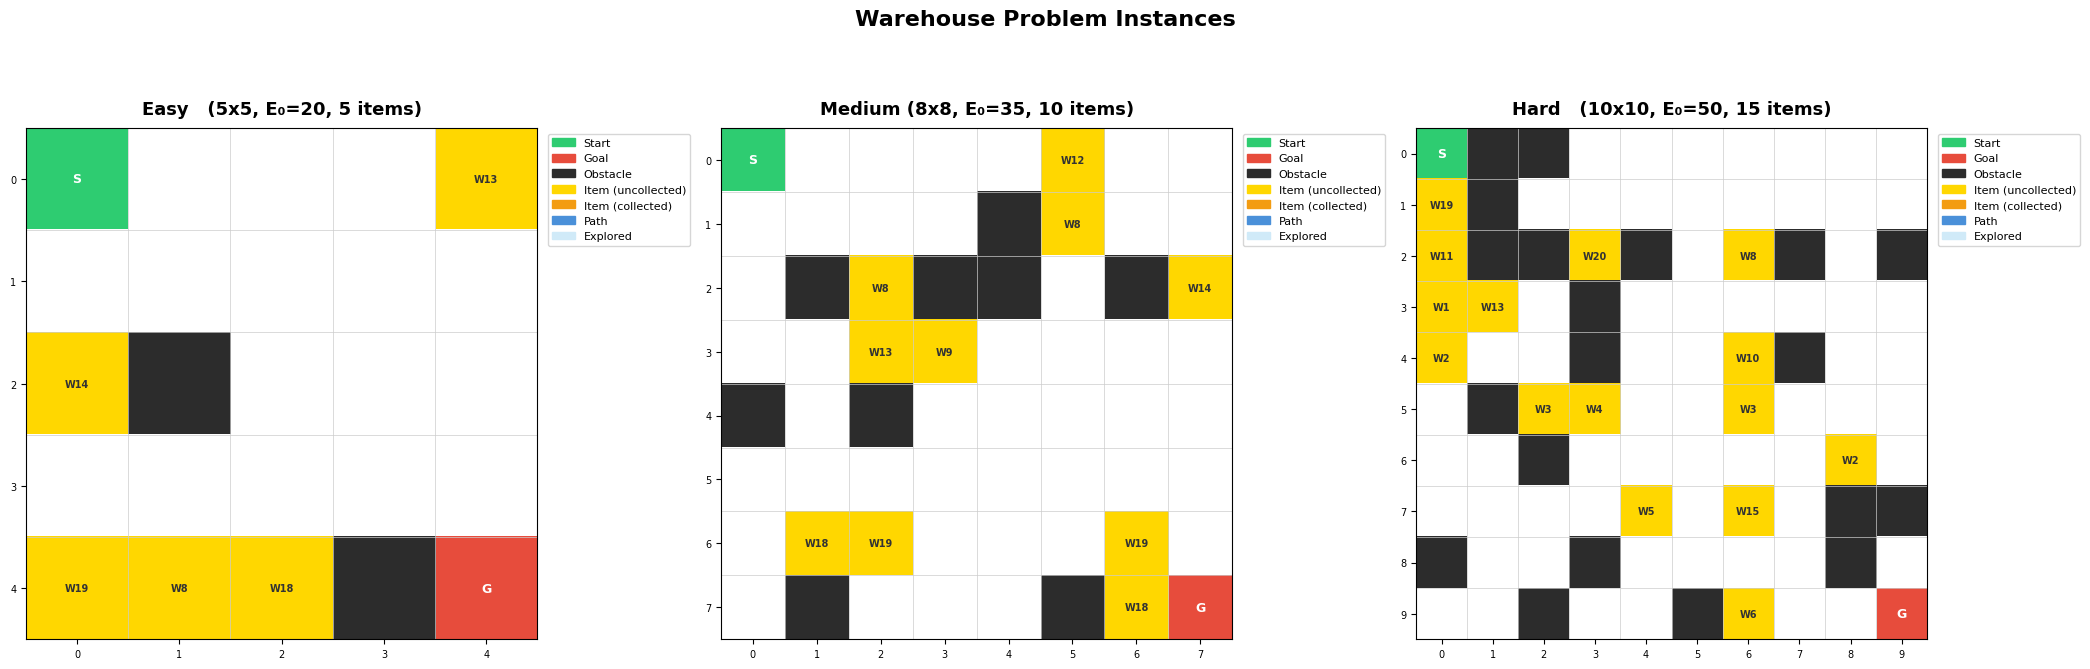

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (env, label) in zip(axes, [
        (env_easy,   'Easy   (5x5, E₀=20, 5 items)'),
        (env_medium, 'Medium (8x8, E₀=35, 10 items)'),
        (env_hard,   'Hard   (10x10, E₀=50, 15 items)'),
]):
    env.render(title=label, ax=ax)

plt.suptitle('Warehouse Problem Instances', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()